# SPAM & NOT SPAM Classification Using Logistic Regression Model

In this analysis, we develop a pipeline that classifies emails as spam or not spam.

**Logistic Regression** was selected because it establishes a highly interpretable, efficient linear baseline that performs well on high-dimensional frequency data. We programmatically ingest our labeled spam dataset, perform exploratory analysis that reveals a moderate 60-40 class split and significant variations in raw feature scales. To ensure model optimization, the data was partitioned and standardized. During training, the model isolated key predictive patterns, heavily weighing excessive capital letters and financial symbols as spam and academic or domain-specific vocabulary as safe markers.

Ultimately, the model achieved a  93% overall accuracy on unseen holdout data. It proved reliable delivering a 92% precision rate that identified the vast majority of legitimate emails. It also maintained a 90% recall rate, intercepting the bulk of actual junk mail. While this linear baseline is effective, the 65 total misclassifications suggest that a Random Forest Classifier that can capture complex feature interactions may be a good alterntive to further reduce false postives and improve overall performance.

# Environment Setup and Data Ingestion

- We ingest  both the raw dataset and its corresponding metadata directly from
the github repository.
- We extract the feature names from the metadata file then construct a complete data set and append the target class label.
- We create the dataframe and verify we have a valid matrix for the model.

In [ ]:
import pandas as pd

# Source data file URLs
data_url = "https://raw.githubusercontent.com/johnnydrodriguez/data620/refs/heads/main/spambase.data"
names_url = "https://raw.githubusercontent.com/johnnydrodriguez/data620/refs/heads/main/spambase.names"

# Read name file
metadata_df = pd.read_csv(
    names_url,
    sep=":",
    comment="|",
    header=None,
    names=["feature", "type"],
    engine="python",
    on_bad_lines="skip")

# Filter data file
valid_metadata = metadata_df[metadata_df["type"].str.contains("continuous|nominal", na=False)]

# Extract features
feature_names = valid_metadata["feature"].str.strip().tolist()

# Append column names
column_names = feature_names + ["spam"]

# Combine data and header names
df = pd.read_csv(data_url, header=None, names=column_names)

# Display shape and head rows
print(f"Matrix shape: {df.shape}")
print(f"Dataset successfully loaded: {df.shape[0]} rows and {df.shape[1]} columns.")
display(df.head())

Matrix shape: (4601, 58)
Dataset successfully loaded: 4601 rows and 58 columns.


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


# Exploratory Data Analysis & Summary Statistics

- We create a summary statistics matrix for all continuous features. The table  shows the widely varying scales across different features - indicating the need for feature scaling and standardization.

- The class frequencies reveal a moderate sixty-forty split between legitimate emails and spam. This establishes a majority-class baseline accuracy of 60%; our predictive model must perform significantly better than this threshold to prove it is learning meaningful patterns rather than simply guessing the most common outcome.


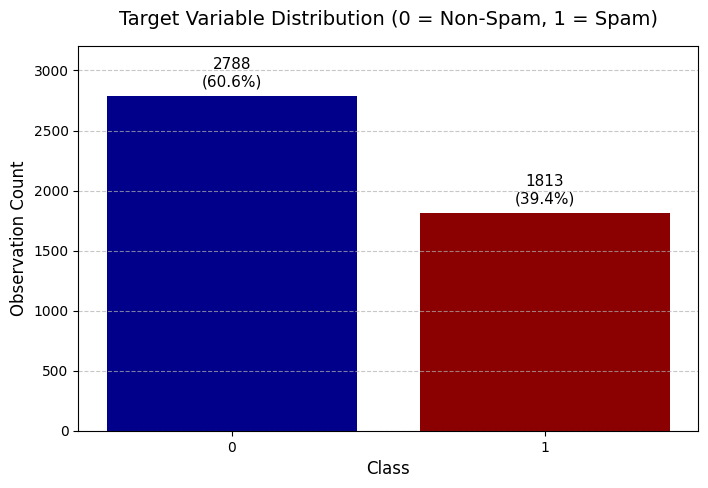

,count,mean,std,min,25%,50%,75%,max
word_freq_make,4601.0,0.104553,0.305358,0.0,0.000,0.000,0.000,4.540
word_freq_address,4601.0,0.213015,1.290575,0.0,0.000,0.000,0.000,14.280
word_freq_all,4601.0,0.280656,0.504143,0.0,0.000,0.000,0.420,5.100
word_freq_3d,4601.0,0.065425,1.395151,0.0,0.000,0.000,0.000,42.810
word_freq_our,4601.0,0.312223,0.672513,0.0,0.000,0.000,0.380,10.000
word_freq_over,4601.0,0.095901,0.273824,0.0,0.000,0.000,0.000,5.880
word_freq_remove,4601.0,0.114208,0.391441,0.0,0.000,0.000,0.000,7.270
word_freq_internet,4601.0,0.105295,0.401071,0.0,0.000,0.000,0.000,11.110
word_freq_order,4601.0,0.090067,0.278616,0.0,0.000,0.000,0.000,5.260
word_freq_mail,4601.0,0.239413,0.644755,0.0,0.000,0.000,0.160,18.180


In [16]:
import matplotlib.pyplot as plt

# Generate summary statistics for all continuous feature
summary_stats = df.drop(columns=['spam']).describe().T

# Compute frequencies and relative proportions for spam not spam target variable
class_counts = df['spam'].value_counts().sort_index()
class_proportions = (class_counts / len(df) * 100).round(1)

# Construct annotation labels
bar_labels = class_counts.astype(str) + "\n(" + class_proportions.astype(str) + "%)"

# Initialize figure canvas and axes
fig, ax = plt.subplots(figsize=(8, 5))

# Create bar chart
bars = ax.bar(class_counts.index.astype(str), class_counts.values, color=['darkblue', 'darkred'])
ax.bar_label(bars, labels=bar_labels, padding=5, fontsize=11)

# Configure axis
ax.set_title("Target Variable Distribution (0 = Non-Spam, 1 = Spam)", fontsize=14, pad=15)
ax.set_xlabel("Class", fontsize=12)
ax.set_ylabel("Observation Count", fontsize=12)
ax.set_ylim(0, class_counts.max() * 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Display plot
plt.show()

# Display stats matrix
display(summary_stats)

# Preprocessing: Feature Scaling

We partition the dataset into a strictly isolated training matrix and a holdout testing matrix; we use stratification to preserve the original class distribution across both subsets.

- We fit a standard scaler to the training data to calculate the mean and standard deviation, and then use those parameters to transform both sets so that every feature has a mean of zero and a standard deviation of one.

- Standardizing the feature space guarantees that variables with drastically different magnitudes contribute proportionally to the model's optimization without arbitrarily dominating the learning process (ie features with extreme values won't skew model training).

- Once standardized, we note that the **mean for all features is 0.0** and the **standard deviation for all features is 1.0**.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Isolate  feature matrix and the target variable
X = df.drop(columns=['spam'])
y = df['spam']

# Partition the dataset into training and testing subsets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# Initialize the parametric standardization
scaler = StandardScaler()

# Compute the mean and standard deviation
X_train_scaled = scaler.fit_transform(X_train_raw)

# Transform the testing partition
X_test_scaled = scaler.transform(X_test_raw)

# Reconstruct the arrays back into Pandas DataFrames
X_train = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X.columns)

# Verify the  dimensions and the normalized statistics
print(f"Training matrix shape: {X_train.shape} | Target shape: {y_train.shape}")
print(f"Testing matrix shape:  {X_test.shape} | Target shape: {y_test.shape}")

# Display the first few rows to confirm zero mean and unit variance
display(X_train.describe().round(3).T.head(10))

Training matrix shape: (3680, 57) | Target shape: (3680,)
Testing matrix shape:  (921, 57) | Target shape: (921,)


,count,mean,std,min,25%,50%,75%,max
word_freq_make,3680.0,-0.0,1.0,-0.341,-0.341,-0.341,-0.341,13.947
word_freq_address,3680.0,0.0,1.0,-0.166,-0.166,-0.166,-0.166,10.719
word_freq_all,3680.0,0.0,1.0,-0.552,-0.552,-0.552,0.255,9.728
word_freq_3d,3680.0,-0.0,1.0,-0.049,-0.049,-0.049,-0.049,30.260
word_freq_our,3680.0,0.0,1.0,-0.473,-0.473,-0.473,0.110,13.117
word_freq_over,3680.0,0.0,1.0,-0.345,-0.345,-0.345,-0.345,20.109
word_freq_remove,3680.0,0.0,1.0,-0.288,-0.288,-0.288,-0.288,17.821
word_freq_internet,3680.0,-0.0,1.0,-0.289,-0.289,-0.289,-0.289,13.095
word_freq_order,3680.0,-0.0,1.0,-0.322,-0.322,-0.322,-0.322,18.115
word_freq_mail,3680.0,-0.0,1.0,-0.373,-0.373,-0.373,-0.121,28.272


# Logistic Regression Model Training & Key Features

We fit the LR model and extract the coefficients to identify which feature weights influence the SPAM / NOT SPAM classification.

- The feature extraction reveals that the model identifies spam primarily through email formatting tactics and financial symbols rather than just vocabulary. Long, uninterrupted strings of capital letters and a high frequency of dollar signs act as strong red flags,  followed by a common opt-out term like "remove".

- The model identifies legitimate emails by relying on professional markers that reflect the specific environment where this data was originally collected. The influence of a specific name ("george"), an academic domain ("edu"), and technical abbreviations ("hp", "cs") indicates that work-related, context-specific emails is a good predictor of a non-spam message.

In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# Instantiate the Logistic Regression estimator
log_reg = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)

# Fit the model to the training features and target variable
log_reg.fit(X_train, y_train)

# Extract the learned coefficients
coefficients = log_reg.coef_.flatten()

# Map the learned weights to their feature names
feature_importance = pd.Series(coefficients, index=X_train.columns)

# Isolate the parameters with the highest magnitude to identify key class indicators
top_spam_indicators = feature_importance.nlargest(5)
top_ham_indicators = feature_importance.nsmallest(5)

# Output most  influential features
print("\n--- Top 5 Features Indicating Spam (Positive Beta) ---")
display(top_spam_indicators.to_frame(name='Coefficient Weight'))

print("\n--- Top 5 Features Indicating Non-Spam (Negative Beta) ---")
display(top_ham_indicators.to_frame(name='Coefficient Weight'))


--- Top 5 Features Indicating Spam (Positive Beta) ---


,Coefficient Weight
capital_run_length_longest,1.547547
char_freq_$,1.369644
capital_run_length_average,1.237725
char_freq_#,0.949163
word_freq_remove,0.866789



--- Top 5 Features Indicating Non-Spam (Negative Beta) ---


,Coefficient Weight
word_freq_george,-4.129591
word_freq_hp,-2.401042
word_freq_cs,-1.605933
word_freq_edu,-1.569001
word_freq_85,-1.478911


# Evaluation Metrics & Confusion Matrix

**Model Metrics**

- An **overall accuracy** of 93% means the model correctly categorizes the vast majority of all incoming messages.

- A **precision score** of 92% indicates that when the model flags an email as spam, it is almost always correct.

- A **recall** of 90% reveals that the model successfully intercepts most of the actual spam  email -- although a small amount will slip through to the inbox.

- An **F1-score** of 91% confirms that the model strikes a reliable balance between catching spam emails and safely delivering actual email communications.

<br>

**Confusion Matrix Results**

- **True Negatives (530)**: Legitimate emails correctly delivered to the inbox.

- **True Positives (326)**: Spam emails correctly routed to the junk folder.

- **False Positives (28)**: Type I Error: The model flagged 28 legitimate, non-spam emails as spam. In an business communication system, this is the most critical failure point. Missing a legitimate email from executive leadership or work colleagues carries a much higher business cost than a cluttered inbox.

- **False Negatives (37)**: Type II Error: The model allowed 37 actual spam emails to bypass the filter and reach the inbox. While this is not ideal for user experience, missed spam messages do not run the risk of disrupting business operations.

              precision    recall  f1-score   support

Non-Spam (0)       0.93      0.95      0.94       558
    Spam (1)       0.92      0.90      0.91       363

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.93       921
weighted avg       0.93      0.93      0.93       921



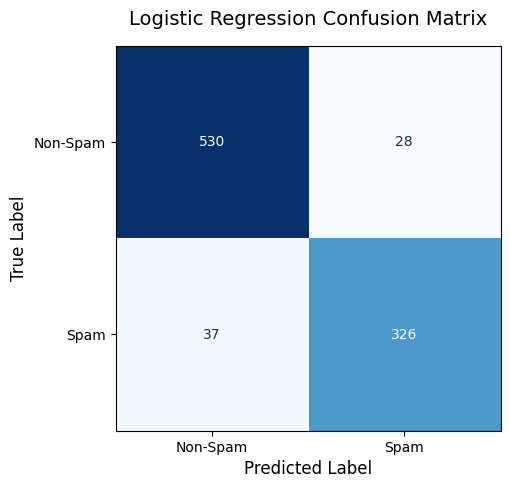

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate class predictions against the unseen testing
y_pred = log_reg.predict(X_test)

# Compute classification metrics
report = classification_report(y_test, y_pred, target_names=['Non-Spam (0)', 'Spam (1)'])

# Output the textual performance metrics to the console
print(report)

# Calculate the confusion matrix array
cm = confusion_matrix(y_test, y_pred)

# Initialize the Matplotlib figure
fig, ax = plt.subplots(figsize=(6, 5))

# Render the matrix visualization
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Spam', 'Spam'])
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')

# Configure plot
ax.set_title("Logistic Regression Confusion Matrix", fontsize=14, pad=15)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)

# Display plot
plt.show()

# Logistic Regression Model Performance Results

The Logistic Regression model is an effective baseline classification model for SPAM/NOT SPAM document classification. An overall accuracy of 93%  demonstrates that the Logistic Regression estimator  converged on a linear decision boundary that separates the majority of the feature space.  It performs well despite it relying entirely on a linear combination of features.

<br>

**Overall Performance**

- Accuracy (0.93): The model correctly classified 93% of all emails in the testing partition.

- Weighted Averages: The dataset contains a slight class imbalance (558 Non-Spam to 363 Spam). However, the weighted average F1-score of 0.93 confirms that the model's performance is not artificially inflated by over-predicting the majority class.

<br>

**Model Limitations**

The 65 total misclassifications (28 FPs + 37 FNs) likely reside in regions of the dataset where the relationship between the word features and spam categorization probability is non-linear.   A potential next step may be to implement a non-parametric, non-linear estimator, such as the Random Forest Classifier, to capture complex hierarchical interactions between features that the LR model cannot capture.